In [ ]:
import numpy as np
import pandas as pd
import math
import astropy.constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units as u
from scipy.signal import find_peaks
from scipy.interpolate import UnivariateSpline


#inputs we set
h_agn = 0.017 * const.pc.cgs.value #height of the AGN in cm
dense_agn = 1e-16 #density of the AGN in cgs units
c = const.c.cgs.value #speed of light in cm/s
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = z_at_value(cosmo.luminosity_distance, 410 * u.Mpc)
print(z)
dist = 410 * 1e6 * const.pc.cgs.value #distance to the AGN in cm (410 Megaparsecs)
jet_angle = 0.05 # about 3 degrees in radians (set by paper)
v_fs = 0.6 * c #velocity of forward shock in cm/s breaks if < 0.7 c
#freq = 1e17 #frequency to test in Hz
freq_list = np.logspace(10, 25, 50000) #frequency range to test in Hz log space does 10^ before for the exponents
sound_speed = 5e6 #sound speed 50 km/s in cm/s
p = 2.5 #top right page 8, the power law index of the electron distribution
pa = np.sin(np.pi/2) #pitch angle set to 90 degrees
e = const.e.esu.value #elementary charge in esu (csg)
m_p = const.m_p.cgs.value #proton mass in cgs
m_e = const.m_e.cgs.value

e_e = 0.3 #page 8 top right
e_b = 0.1 #page 8 top right
xi = 1 #page 7 top left
radius = 5e8


0.08969458230111924 redshift


In [ ]:
#beta fs 
b_fs = v_fs / c #page 2 bottom right

A_emitting = np.pi * jet_angle**2 * radius**2

def find_flux_thermal(B_v, d):
    #B_v = ((2 * const.h.cgs.value) / const.c.cgs.value**2) * freq**3 * np.exp(-(const.h.cgs.value * freq) / (const.k_B.cgs.value * t))
    F_nu = (A_emitting / (4 * np.pi * d**2)) * B_v
    return F_nu

def planck_fxn(filter, t):
    """Planck's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like 
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = (((2*const.h.cgs.value*(filter**3))/(const.c.cgs.value**2)))*((1/(np.exp((const.h.cgs.value*filter)/(const.k_B.cgs.value*t))-1)))
    return B

#for when b is greater than 0.03 but less than 1 use wien in graph
def wien_fxn(filter, t):

    """Wien's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = ((2 * const.h.cgs.value * (filter**3)) / (const.c.cgs.value**2)) * np.exp(-((const.h.cgs.value * filter)/(const.k_B.cgs.value * t)))
    #B = filter**3 * np.exp(-((h * filter)/(k * t)))
    return B

def find_b_fs():
    b_fsv = v_fs / c
    return b_fsv

def find_l_sh(jet_angle, h_agn, dense_agn, b_fs):
    l_sh = 5e44# 5e43 * (jet_angle/0.05)**2 * (h_agn/5.245651888535325e+16)**2 * (dense_agn/1e-16) * (b_fs/0.1)**3 #eq 5
    return l_sh

def find_B_sf(a_gamma_sf, dense_agn):
    print("A_gamma_sf ", a_gamma_sf)
    B_sf = 600 * ((a_gamma_sf/1.5)**(0.5)) * ((e_b/0.1)**(0.5)) * ((dense_agn/1e-16)**(0.5))
    return B_sf

def solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case):
    gamma_a = gamma_m  # set equal to gamma_m for start guess

    #having the final values set to be an option to print
    final_tq = None
    final_cq = None
    final_tc = None

    for _ in range(100):  #looping it to find gamma a
        if case == 1:
            gamma_1 = gamma_a #when gamma m is larger than gamma a
            gamma_2 = gamma_m
            q = 2
        else:
            gamma_1 = gamma_m #when gamma a is larger than gamma m
            gamma_2 = gamma_max
            q = p #2.5

        #eq 20 (cooling timescale)
        tc_ga = 30 * ((e_b/0.1)**-1) * ((((gamma_sf-1)*(4*gamma_sf+3))/1.5)**-1) * ((dense_agn/1e-16)**-1) * ((gamma_sf/1.2)**-1) * ((gamma_a/60)**-1)

        delta_shell = tc_ga * v_fs

        #eq 20 (synchotron self absorption)
        ratio = gamma_2 / gamma_1

        if ratio <= 0: #case where gamma 2 is negatice or or it wont be possible
            return np.nan

        denom = 1 - (ratio ** (-q+1))
        
        
         # if gamma2/gamma1 to the power of (-q+1) is 1 the denom is negative and breaks
        if abs(denom) < 1e-10:
            denom = 1e-10

        # eq 22 (synchotron self absorption)
        tq = (np.pi/(3*np.sqrt(3))) * (((q**2 + q - 2)*(gamma_1**-5))/(denom)) * ((e * dense_sf * delta_shell)/(B_sf * pa * m_p))

        #eq 23 (modified to be Cq+1)
        cq_1 = ((2**(((q+2)/2)))/(q+2)) * math.gamma(((q+1)/4)-(1/12)) * math.gamma(((q+1)/4)+(19/12))
        # we need to clarify this with Hiromichi -- running q+1 and q (no modifications) will push the curve over in freq space
        #cq_1 = ((2**(((q+1)/1)))/(q+2)) * math.gamma(((q)/4)-(1/12)) * math.gamma(((q)/4)+(19/12))
        #storing the values used to get final gamma_a

        if np.isfinite(tq) and np.isfinite(cq_1) and np.isfinite(tc_ga): #this only picks real numbers when the eq doesnt break
            final_tq = tq
            final_cq = cq_1
            final_tc = tc_ga

        #eq 21 
        gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))

        if abs(gamma_new - gamma_a)/gamma_a < 1e-3:
            return gamma_new, final_tq, final_cq, final_tc
        gamma_a = gamma_new
    return gamma_a, final_tq, final_cq, final_tc

def find_gammas_tq_cq_tc(b_fs, dense_agn):
    #gamma equations
    gamma_fs = 1/(np.sqrt(1 - b_fs**2)) 

    if b_fs < 0.7:
        gamma_sf = (7/6) * gamma_fs #from hiromichi
        print(f"7/6 gamma_fs = gamma_sf = {gamma_sf}")
    else:
        gamma_sf = gamma_fs / (np.sqrt(2)) #page 5 top left
        
    dense_sf = dense_agn * (((gamma_sf)+1)/((gamma_sf)-1)) # CHANGED 5/3 to gamma_sf density of shock fluid (eq 34 from emilys notes)

    #beta_sf = v_sf / c#b_fs + c1 * (1+ ((gamma_sf)+1)/(2 * (gamma_sf)) * ((p2/p1)-1))**0.5
    v_sf = c * np.sqrt(1 - (1 / gamma_sf**2))

    beta_sf = v_sf/c
    #beta_sf eq CHANGED 5/3 to gamma_sf
    a_gamma_sf = (gamma_sf-1) * ((4*gamma_sf)+3) #left of eq 2

    gamma_sf_f = gamma_sf**(1 + np.sqrt(3)) #page 5 top left
    gamma_m = e_e * ((p-2) / (p-1)) * (m_p/m_e) * (gamma_sf - 1) + 1 # eqn 7 of fab + p 2008 adds +1!! ASK HIROMICHI # 40 * (e_e/0.3) * ((gamma_sf-1)/0.2) #eq 16
    gamma_max = 1e6 * (xi**(-0.5)) * (beta_sf/0.5) * ((a_gamma_sf/1.5)**(-0.25)) * ((e_b/0.1)**(-0.25)) * ((dense_agn/1e-16)**(-0.25)) #eq 17

    B_sf = find_B_sf(a_gamma_sf, dense_agn) # need her for gamma_a solvingggg

    gamma_a_small, tq_small, cq_small, tc_small = solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case=1)
    gamma_a_big, tq_big, cq_big, tc_big = solve_gamma_a(gamma_m, gamma_max, gamma_sf, B_sf, dense_sf, case=2)

    if gamma_a_small < gamma_m:
        gamma_a = gamma_a_small
        tq_final = tq_small
        cq_final = cq_small
        tc_final = tc_small

    else:
        gamma_a = gamma_a_big
        tq_final = tq_big
        cq_final = cq_big
        tc_final = tc_big

    print(f"gamma_fs: {gamma_fs}")
    print(f"gamma_a_small: {gamma_a_small}")
    print(f"gamma_sf: {gamma_sf}")
    print(f"A_gamma_sf: {a_gamma_sf}" )
    print(f"gamma_m: {gamma_m}")
    print(f"gamma_max: {gamma_max}" )
    print(f"gamma_a: {gamma_a}" )
    print(tq_small, cq_small, tc_small)
    print(tq_big, cq_big, tc_big)
    print(f"Final tq: {tq_final}")
    print(f"Final cq_1: {cq_final}")
    print(f"Final tc: {tc_final}")

    return gamma_fs, gamma_sf, a_gamma_sf, gamma_a, gamma_sf_f, gamma_m, gamma_max, B_sf, tq_final, cq_final, tc_final

def find_l_syn(b_fs, gamma_fs, gamma_sf_f, l_sh):
    #L_syn variable 
    f_dilution = 1 #page 6 left of eq 16
    Yssc = (e_e / e_b)**(1/3) #page 8 top left
    Y2ndIC = (e_e / e_b)**(2/3) #page 8 top left
    #page 6 under eq 15
    if b_fs * gamma_fs <= 1: 
        f_beaming = 1
    elif b_fs * gamma_fs > 1:
        f_beaming = 2 * (gamma_sf_f**2)
    l_syn = e_e * f_beaming * f_dilution * (l_sh/(1 + Yssc + Y2ndIC)) # (eq 15)
    return l_syn

In [53]:
gamma_fs, gamma_sf, a_gamma_sf, gamma_a, gamma_sf_f, gamma_m, gamma_max, B_sf, tq_final, cq_final, tc_final = find_gammas_tq_cq_tc(b_fs, dense_agn)
l_sh = find_l_sh(jet_angle, h_agn, dense_agn, b_fs)
l_syn = find_l_syn(b_fs, gamma_fs, gamma_sf_f, l_sh)
print(l_sh)
print(l_syn)


7/6 gamma_fs = gamma_sf = 1.4583333333333335
A_gamma_sf  4.0486111111111125
gamma_fs: 1.25
gamma_a_small: nan
gamma_sf: 1.4583333333333335
A_gamma_sf: 4.0486111111111125
gamma_m: 85.15699753266674
gamma_max: 1135744.386113631
gamma_a: 52.46341123915338
-2.7884084584491925e-12 1.6122661015415265 0.2772405042392587
0.026783414062704358 1.602393838648818 10.456579749201236
Final tq: 0.026783414062704358
Final cq_1: 1.602393838648818
Final tc: 10.456579749201236
5e+44
3.316871777305563e+43


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_41196/1978754099.py:119: RuntimeWarning: invalid value encountered in scalar power
  gamma_new = gamma_m * ((tq * cq_1)**(1/(q+4)))


In [54]:
def temp_fxn(v_fs, dens):
    """
    Calculate the temperature t based on velocity of forward shock and other physical parameters. All parameters should be in CGS units

    Parameters
    ----------
    v_fs : float
        Velocity of the forward shock in m/s.
    dens : float
        Density of AGN disk.
    m_p : float
        Proton mass.
    c : float
        Speed of light.
    k : float
        Boltzmann constant.

    Returns
    -------
    t : float
        Calculated temperature.
    """
    b_fs = v_fs / c
    gamma_fs = 1 / np.sqrt(1 - b_fs**2)
    print(b_fs*gamma_fs)
    gamma_fs_f = gamma_fs**(1 + np.sqrt(3))
    gamma_sf = gamma_fs / np.sqrt(2)
    gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
    n = dens / m_p
    print(f"{n:.2e}")

    if b_fs * gamma_fs <= 0.03:
        T_bo = 1e4 * ((b_fs / 0.02)**0.5) * ((dens / 1e-16)**0.25)
        E_bo = 2.8 * const.k_B.cgs.value * T_bo
    elif b_fs * gamma_fs > 0.03 and b_fs * gamma_fs <= 1:
        T_bo = (10**(0.975 + (1.735 * ((b_fs / 0.1)**0.5)) + ((0.26 - 0.08 * ((b_fs / 0.1)**0.5)) * np.log10(n / 1e15)))) * 1e4
        theta_j = 0.05  
        L_bo = (5e43 * (theta_j / 0.05)**2 * (h_agn / 5e16)**2 * (dense_agn / 1e-16) * (b_fs / 0.1)**3)
    elif b_fs * gamma_fs > 1:
        T_bo = (gamma_sf_f * 5e4) / const.k_B.cgs.value
    if b_fs >= 1:
        print("Velocity is greater than speed of light, using beta = 0.98 instead")
        b_fs = 0.98
        gamma_fs = 1 / np.sqrt(1 - b_fs**2)
        gamma_sf = gamma_fs / np.sqrt(2)
        gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
        T_bo = (gamma_sf_f * 5e4) / const.k_B.cgs.value

    return T_bo

In [ ]:
#NON- THERMAL SED function

def compute_nonthermal_sed(
    freq_list: np.ndarray,
    dist: float,
    l_syn: float,
    gamma_sf: float,
    B_sf: float,
    gamma_m: float,
    gamma_max: float,
    gamma_a: float,
    p: float):

    #freq_sync = 2e9 * (gamma_sf / 1.2) * (B_sf / 600)
    #freq_m = 3e12 * (gamma_m / 40)**2 * (freq_sync / 2e9)
    #freq_max = 2e21 * (gamma_max / 1e6)**2 * (freq_sync / 2e9)
    #freq_a = 7e12 * (gamma_a / 60)**2 * (freq_sync / 2e9)
    gamma_a = 59
    gamma_m = 35
    freq_sync = 2e9 
    freq_m    = 3e12 
    freq_max  = 2e21 
    freq_a    = 7e12
    A_gamma_fs = (gamma_fs - 1) * (4 * gamma_fs + 3)
    e_fs = A_gamma_fs * dense_agn * c**2
    B_fs = (8 * np.pi * e_b * e_fs)**(1/2)
    t_break = (0.3 * u.yr).to('s').value
    factor = (6 * np.pi * const.m_e.cgs.value * c) / (const.sigma_T.cgs.value * B_sf**2 * gamma_sf * t_break) #eq 19
    gamma_c = max(1, factor) #eq 19
    freq_c =  ((gamma_fs * gamma_c**2) / (1 + z)) * (e * B_fs)
    freq_a_ssc = (4/3) * gamma_a**2 * freq_a
    freq_m_ssc = (4/3) * gamma_m**2 * freq_m

    freq_a_2sc = (4/3) * gamma_a**2 * freq_a_ssc # i should check if this should be gamma_a or a dif gamma
    freq_m_2sc = (4/3) * gamma_m**2 * freq_m_ssc

    print(f"nu_sync  = {freq_sync:.3e} Hz")
    print(f"nu_a  = {freq_a:.3e} Hz")
    print(f"nu_a_ssc  = {freq_a_ssc:.3e} Hz")
    print(f"nu_a_2sc  = {freq_a_2sc:.3e} Hz")
    print(f"nu_c  = {freq_c:.3e} Hz")
    print(f"nu_m  = {freq_m:.3e} Hz")
    print(f"nu_m_ssc  = {freq_m_ssc:.3e} Hz")
    print(f"nu_m_2sc  = {freq_m_2sc:.3e} Hz")
    print(f"nu_max= {freq_max:.3e} Hz")
    print(f"Regime: {'FAST' if freq_c < freq_m else 'SLOW'} cooling, "
          f"nu_a {'<' if freq_a < min(freq_c, freq_m) else '>'} min(nu_c, nu_m)")

    f = np.asarray(freq_list, dtype=float)

    sa = np.zeros(len(f))
    ssc = np.zeros(len(f))
    o2_ic = np.zeros(len(f))
    o2_ic2 = np.zeros(len(f))

    if freq_a < freq_m:                          
        print("va < vm")
        print("fahh")
        chosen = np.select(
            condlist=[
                (f > freq_m)  & (f < freq_max),
                (f > freq_a)  & (f < freq_m),
                (f > freq_sync) & (f < freq_a),
            ],
            choicelist=[
                (f / freq_m) ** (-(p+1) / 2),
                (f / freq_m) ** (1 / 2),
                (f / freq_a) ** 3 * (freq_a / freq_m) ** (1 / 2),
            ],
            default=0.0,
        )

        sa = chosen

    if freq_m < freq_a:                                       
        print("vm < va")
        chosen = np.select(
            condlist=[
                (f > freq_a) & (f < freq_max),
                f < freq_a,
            ],
            choicelist=[
                (f / freq_m) ** ((-p+1) / 2) + np.exp(1 - (f / freq_a) ** (1 / 2)),
                (f / freq_a) ** 3,
            ],
            default=0.0,
        )
        ssc = chosen

    if freq_c < freq_m and freq_m < freq_a:        
        print("v_c < v_m < v_a")
        
        chosen = np.select(
            condlist=[
                (f > freq_a_ssc),
                f < freq_a_ssc,
            ],
            choicelist=[
                np.exp(1 - (f / freq_a_ssc)**(1/2)) + (f / freq_m_ssc)**((1-p)/2),
                (f / freq_a_ssc) ** 2,
            ],
            default=0.0,
        )
        Yssc = (e_e / e_b)**(1/3) #page 8 left side
        o2_ic = Yssc * chosen

    if freq_c < freq_m and freq_m < freq_a:        
        print("2nd order inv. C. scattering")
        chosen2 = np.select(
            condlist=[
                (f > freq_a_2sc),
                f < freq_a_2sc,
            ],
            choicelist=[
                np.exp(1 - (f / freq_a_2sc)**(1/2)) + (f / freq_m_2sc)**((1-p)/2),
                (f / freq_a_2sc) ** 2,
            ],
            default=0.0,
        )
        Y2sc = (e_e / e_b)**(2/3) #page 8 left side
        o2_ic2 = Y2sc * chosen2
    total = sa + ssc + o2_ic + o2_ic2
    luminosity = l_syn * total
    flux = luminosity / (4 * np.pi * dist**2)

    return pd.DataFrame({"freq": f, "luminosity": luminosity, "flux": flux})

df = compute_nonthermal_sed(freq_list=freq_list, dist=dist, l_syn=l_syn, gamma_sf=gamma_sf, B_sf=B_sf, gamma_m=gamma_m, gamma_max=gamma_max, gamma_a=gamma_a, p=p)

nu_sync  = 2.000e+09 Hz
nu_a  = 7.000e+12 Hz
nu_a_ssc  = 3.249e+16 Hz
nu_a_2sc  = 1.508e+20 Hz
nu_c  = 3.703e-07 Hz
nu_m  = 3.000e+12 Hz
nu_m_ssc  = 4.900e+15 Hz
nu_m_2sc  = 8.003e+18 Hz
nu_max= 2.000e+21 Hz
Regime: FAST cooling, nu_a > min(nu_c, nu_m)
vm < va
v_c < v_m < v_a
2nd order inv. C. scattering


In [56]:
#Thermal

def compute_thermal_sed(v_fs, dense_agn):
    T_bo = temp_fxn(v_fs, dense_agn)

    if b_fs*gamma_fs <= 0.03:
        B_v = planck_fxn(freq_list, T_bo) 
    elif b_fs*gamma_fs > 0.03:
        B_v = wien_fxn(freq_list, T_bo) 

    F_nu = find_flux_thermal(B_v, dist)
    nu_F_nu_thermal = F_nu * freq_list
    
    return nu_F_nu_thermal

nu_F_nu_thermal = compute_thermal_sed(v_fs, dense_agn)

0.75
5.98e+07


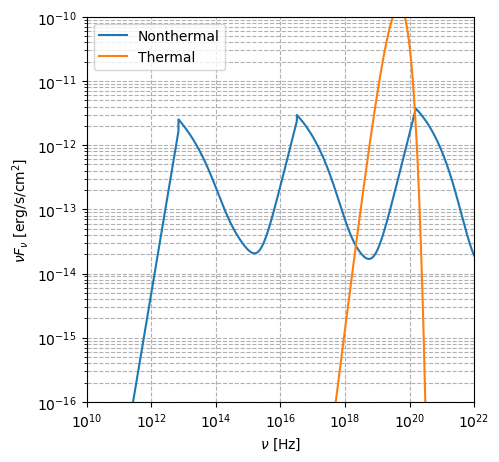

In [57]:
plt.figure(figsize=(5,5))
plt.plot(df['freq'], df['flux'], label="Nonthermal")
plt.plot(freq_list, nu_F_nu_thermal, label="Thermal")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e10,1e22)
plt.ylim(1e-16, 1e-10)
plt.xlabel(r"$\nu$ [Hz]")
plt.ylabel(r"$\nu F_{\nu}$ [erg/s/cm$^2$]")
plt.legend(loc='best')
plt.grid(True, which="both", linestyle="--")
plt.show()

388855.63670775783


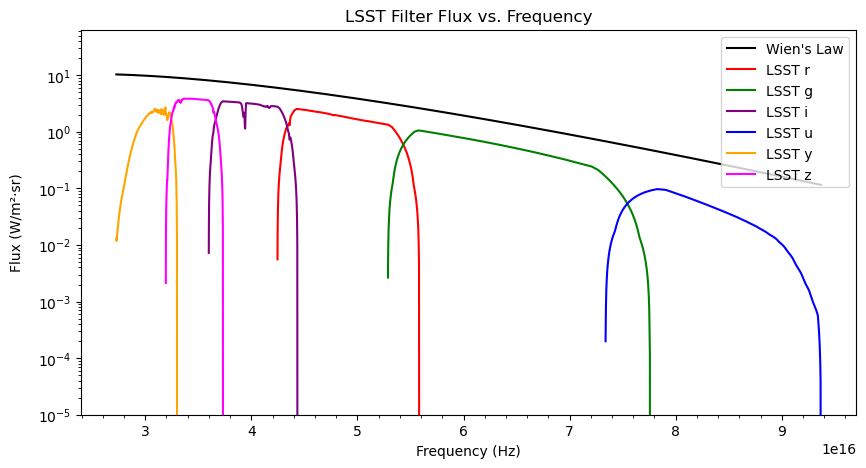

(1806, 2)
[[3.86900e+03 2.01547e-03]
 [3.87000e+03 2.52861e-03]
 [3.87100e+03 3.03006e-03]
 ...
 [5.66700e+03 2.47378e-03]
 [5.66800e+03 1.66397e-03]
 [5.66900e+03 8.32081e-04]]


In [ ]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.constants import h, c, k_B, m_p, R_sun, au, pc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parameters that you can change for new model
c_factor = 0.1 #factor to change the speed of light for the velocity of forward shock
v_fs = c_factor * c.cgs.value #velocity of forward shock in m/s
dens = 1e-16 #density of agn disk

# Constants used 
#t = 5800 #Temp of sun for now can change for what we are looking at 
rad = 5e8 #Radius of sun in meters for now will change to bh later
d = 410 * 1e6 * const.pc.cgs.value #distance from earth to sun in meters change later to distance to agn
h = h.cgs.value #Planck constant
c = c.cgs.value #speed of light
k = k_B.cgs.value #Boltzmann constant
m_p = m_p.cgs.value #proton mass
pi = np.pi #Pi constant
jet_angle = 0.05 #jet angle in radians


# Function to calculate temperature based on velocity of forward shock and density
def temp_fxn(v_fs, dens, m_p, c, k):
    """
    Calculate the temperature t based on velocity of forward shock and other physical parameters. All parameters should be in CGS units

    Parameters
    ----------
    v_fs : float
        Velocity of the forward shock in m/s.
    dens : float
        Density of AGN disk.
    m_p : float
        Proton mass.
    c : float
        Speed of light.
    k : float
        Boltzmann constant.

    Returns
    -------
    t : float
        Calculated temperature.
    """
    b_fs = v_fs / c
    gamma_fs = 1 / np.sqrt(1 - b_fs**2)
    gamma_fs_f = gamma_fs**(1 + np.sqrt(3))
    gamma_sf = gamma_fs / np.sqrt(2)
    gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
    n = dens / m_p

    if b_fs * gamma_fs <= 0.03:
        t = 1e4 * ((b_fs / 0.02)**0.5) * ((dens / 1e-16)**0.25)
    elif b_fs * gamma_fs > 0.03 and b_fs * gamma_fs <= 1:
        t = (10**(0.975 + (1.735 * ((b_fs / 0.1)**0.5)) + ((0.26 - 0.08 * ((b_fs / 0.1)**0.5)) * np.log10(n / 1e15)))) * 1e4
    elif b_fs * gamma_fs > 1:
        t = (gamma_sf_f * 5e4) / k
    if b_fs >= 1:
        print("Velocity is greater than speed of light, using beta = 0.98 instead")
        b_fs = 0.98
        gamma_fs = 1 / np.sqrt(1 - b_fs**2)
        gamma_sf = gamma_fs / np.sqrt(2)
        gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
        t = (gamma_sf_f * 5e4) / k
    return t

# Plancks law for frequency in graph
def planck_fxn(filter, t):
    """Planck's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like 
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = (((2*h*(filter**3))/(c**2)))*((1/(np.exp((h*filter)/(k*t))-1)))
    return B

#for when b is greater than 0.03 but less than 1 use wien in graph
def wien_fxn(filter, t):

    """Wien's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = ((2 * h * (filter**3)) / (c**2)) * np.exp(-((h * filter)/(k * t)))
    return B


def read_filter(path):
    """Reads a 2-column LSST filter file using NumPy."""
    return np.loadtxt(path)

# Reading and convering the LSST filter data
g = read_filter('../data/filters//LSST_g.dat')
# green filter from 3865-5669
i = read_filter('../data/filters//LSST_i.dat')
#red filter from 5371-7059
r = read_filter('../data/filters//LSST_r.dat')
# infrared filter from 6761-8329
u = read_filter('../data/filters//LSST_u.dat')
# ultraviolet filter from 3201-4085
y = read_filter('../data/filters//LSST_y.dat')
# y filter from 9085-10989
z = read_filter('../data/filters//LSST_z.dat')
# z filter from 8031-9385

r_filter, r_eff = r[:,0], r[:,1] # 0 for wavelength 1 for transmission
g_filter, g_eff = g[:,0], g[:,1]
i_filter, i_eff = i[:,0], i[:,1]
u_filter, u_eff = u[:,0], u[:,1]
y_filter, y_eff = y[:,0], y[:,1]
z_filter, z_eff = z[:,0], z[:,1]

r_wave = r_filter * 1e-12 # angstroms to cm 
g_wave = g_filter * 1e-12
i_wave = i_filter * 1e-12
u_wave = u_filter * 1e-12
y_wave = y_filter * 1e-12
z_wave = z_filter * 1e-12

# converting wavelength to frequency
r_freq = (c/100)/r_wave #dividing by 100 to convert cm to m
g_freq = (c/100)/g_wave
i_freq = (c/100)/i_wave
u_freq = (c/100)/u_wave
y_freq = (c/100)/y_wave
z_freq = (c/100)/z_wave


b_fs = v_fs / c
gamma_fs = 1 / np.sqrt(1 - b_fs**2)

t = temp_fxn(v_fs, dens, m_p, c, k)  # Calculate temperature based on forward shock velocity and density

# Planck's law for frequency (for when b_fs * gamma_fs <= 0.03)
planck_r = planck_fxn(r_freq,t)
planck_g = planck_fxn(g_freq,t)
planck_i = planck_fxn(i_freq,t) 
planck_u = planck_fxn(u_freq,t)
planck_y = planck_fxn(y_freq,t)
planck_z = planck_fxn(z_freq,t)

# Combining the filter data and planck law 

r_planck = planck_r * r_eff #total output for given filter in planck law
g_planck = planck_g * g_eff
i_planck = planck_i * i_eff
u_planck = planck_u * u_eff
y_planck = planck_y * y_eff
z_planck = planck_z * z_eff

r_total = sum(r_planck) #combinging the 1600ish values in each filter for total output
g_total = sum(g_planck)
i_total = sum(i_planck)
u_total = sum(u_planck)
y_total = sum(y_planck)
z_total = sum(z_planck)

#ratio of highest output to other filters
r_ratio = r_total / i_total
g_ratio = g_total / i_total
i_ratio = i_total / i_total
u_ratio = u_total / i_total
y_ratio = y_total / i_total
z_ratio = z_total / i_total

#Planck law graph
total_wave = np.concatenate((r_wave, g_wave, i_wave, u_wave, y_wave, z_wave)) #combining all the wavelengths in one 
planck_total = np.concatenate((planck_r, planck_g, planck_i, planck_u, planck_y, planck_z)) #Full Planck law
trans_total = np.concatenate((r_planck, g_planck, i_planck, u_planck, y_planck, z_planck))
total_freq = np.concatenate((r_freq, g_freq, i_freq, u_freq, y_freq, z_freq))#sorting the frequency values
sorted_freq = np.sort(total_freq)

emitting_area = np.pi * jet_angle**2 * rad**2 #emitting area of the jet
dist_area = emitting_area / (4 * np.pi * d**2) #distance to the source

# To make plancks law graph smooth 
total_index = np.argsort(total_freq)
total_wave = total_wave[total_index]
planck_total = (planck_total[total_index])  

# planck law based on emitting area and distance
planck_nu = planck_total * dist_area

# nu * freq_nu_planck
nu_planck_nu = planck_nu * sorted_freq

# Wien's law for frequency (used when b_fs * gamma_fs > 0.03)
wien_r = wien_fxn(r_freq, t)
wien_g = wien_fxn(g_freq, t)
wien_i = wien_fxn(i_freq, t) 
wien_u = wien_fxn(u_freq, t)
wien_y = wien_fxn(y_freq, t)
wien_z = wien_fxn(z_freq, t)

wien_freq = np.concatenate((wien_r, wien_g, wien_i, wien_u, wien_y, wien_z)) #combining all the wien values
wien_total = (wien_freq[total_index])  # sorting the wien values 

# wien law based on emitting area and distance
wien_nu = wien_total * dist_area

#nu * freq_nu_wien
nu_wien_nu = wien_nu * sorted_freq

r_wien = wien_r * r_eff #total output for given filter in wien law
g_wien = wien_g * g_eff
i_wien = wien_i * i_eff
u_wien = wien_u * u_eff
y_wien = wien_y * y_eff
z_wien = wien_z * z_eff

# when b  is greater than 1 force it to use beta = 1- precision of instruement and give a warning 

print(t)

# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(sorted_freq, planck_total, color='black', label="Planck's Law")
    plt.plot(r_freq, r_planck, color='red', label='LSST r')
    plt.plot(g_freq, g_planck, color='green', label='LSST g')
    plt.plot(i_freq, i_planck, color='purple', label='LSST i')
    plt.plot(u_freq, u_planck, color='blue', label='LSST u')
    plt.plot(y_freq, y_planck, color='orange', label='LSST y')
    plt.plot(z_freq, z_planck, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    plt.plot(sorted_freq, wien_total, color='black', label="Wien's Law")
    plt.plot(r_freq, r_wien, color='red', label='LSST r')
    plt.plot(g_freq, g_wien, color='green', label='LSST g')
    plt.plot(i_freq, i_wien, color='purple', label='LSST i')
    plt.plot(u_freq, u_wien, color='blue', label='LSST u')
    plt.plot(y_freq, y_wien, color='orange', label='LSST y')
    plt.plot(z_freq, z_wien, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale

#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W/m²·sr)", labelpad=10)
plt.ylim(bottom=1e-5) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Flux vs. Frequency")
plt.legend(loc='upper right')

plt.show()

print(g.shape)
print(g[5:])   # last 5 rows

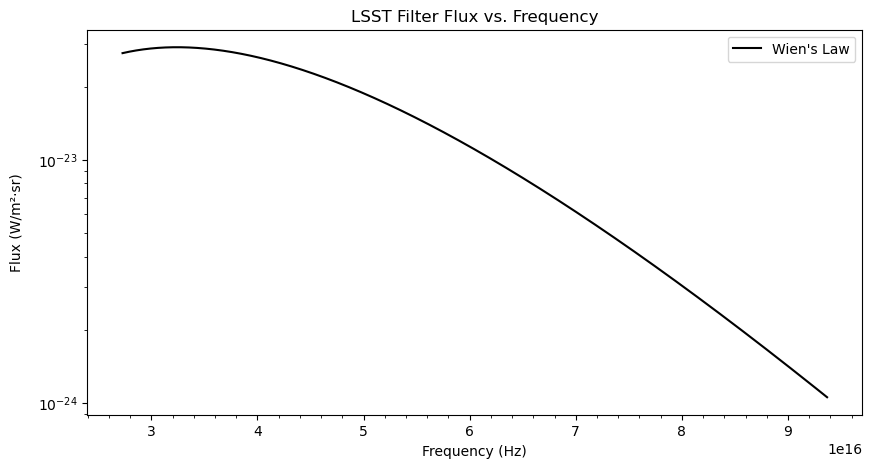

In [61]:

# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(sorted_freq, nu_planck_nu, color='black', label="Planck's Law")
    # plt.plot(r_freq, r_planck, color='red', label='LSST r')
    # plt.plot(g_freq, g_planck, color='green', label='LSST g')
    # plt.plot(i_freq, i_planck, color='purple', label='LSST i')
    # plt.plot(u_freq, u_planck, color='blue', label='LSST u')
    # plt.plot(y_freq, y_planck, color='orange', label='LSST y')
    # plt.plot(z_freq, z_planck, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    plt.plot(sorted_freq, nu_wien_nu, color='black', label="Wien's Law")
    # plt.plot(r_freq, r_wien, color='red', label='LSST r')
    # plt.plot(g_freq, g_wien, color='green', label='LSST g')
    # plt.plot(i_freq, i_wien, color='purple', label='LSST i')
    # plt.plot(u_freq, u_wien, color='blue', label='LSST u')
    # plt.plot(y_freq, y_wien, color='orange', label='LSST y')
    # plt.plot(z_freq, z_wien, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale

#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W/m²·sr)", labelpad=10)
#plt.ylim(bottom=1e-5) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Flux vs. Frequency")
plt.legend(loc='upper right')

plt.show()

256914.37139363753


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_46112/3332139766.py:89: RuntimeWarning: overflow encountered in exp
  B = (((2*h*(filter**3))/(c**2)))*((1/(np.exp((h*filter)/(k*t))-1)))


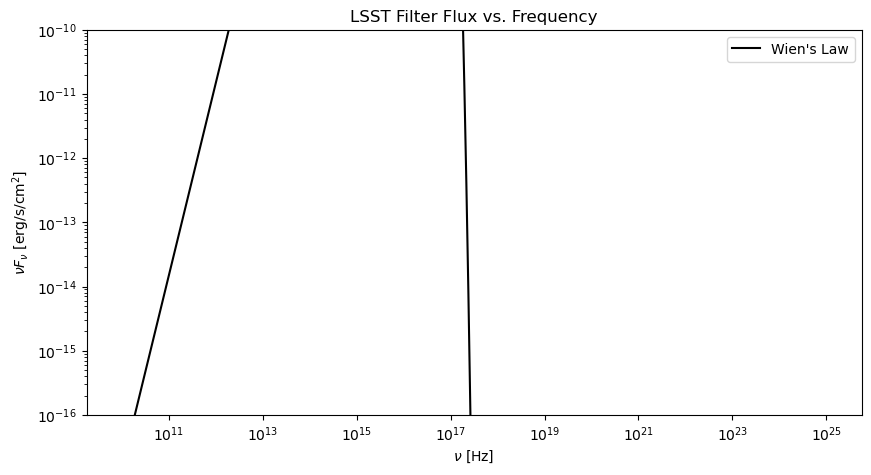

In [11]:
#TESTING

import numpy as np
import pandas as pd
from astropy.io import fits
import astropy.constants as const
from astropy.constants import h, c, k_B, m_p, R_sun, au, pc
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parameters that you can change for new model
c_factor = 0.1 #factor to change the speed of light for the velocity of forward shock
v_fs = c_factor * c.cgs.value #velocity of forward shock in m/s
dens = 1e-16 #density of agn disk

# Constants used 
#t = 5800 #Temp of sun for now can change for what we are looking at 
rad = 5e8 #Radius of sun in meters for now will change to bh later
d = 410 * 1e6 * const.pc.cgs.value #distance from earth to sun in meters change later to distance to agn
h = h.cgs.value #Planck constant
c = c.cgs.value #speed of light
k = k_B.cgs.value #Boltzmann constant
m_p = m_p.cgs.value #proton mass
pi = np.pi #Pi constant
jet_angle = 0.05 #jet angle in radians
freq_list = np.logspace(10, 25, 50000)  # Frequency range for SED calculation log space does 10^ before

# Function to calculate temperature based on velocity of forward shock and density
def temp_fxn(v_fs, dens, m_p, c, k):
    """
    Calculate the temperature t based on velocity of forward shock and other physical parameters. All parameters should be in CGS units

    Parameters
    ----------
    v_fs : float
        Velocity of the forward shock in m/s.
    dens : float
        Density of AGN disk.
    m_p : float
        Proton mass.
    c : float
        Speed of light.
    k : float
        Boltzmann constant.

    Returns
    -------
    t : float
        Calculated temperature.
    """
    b_fs = v_fs / c
    gamma_fs = 1 / np.sqrt(1 - b_fs**2)
    gamma_fs_f = gamma_fs**(1 + np.sqrt(3))
    gamma_sf = gamma_fs / np.sqrt(2)
    gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
    n = dens / m_p

    if b_fs * gamma_fs <= 0.03:
        t = 1e4 * ((b_fs / 0.02)**0.5) * ((dens / 1e-16)**0.25)
    elif b_fs * gamma_fs > 0.03 and b_fs * gamma_fs <= 1:
        t = (10**(0.975 + (1.735 * ((b_fs / 0.1)**0.5)) + ((0.26 - 0.08 * ((b_fs / 0.1)**0.5)) * np.log10(n / 1e15)))) * 1e4
    elif b_fs * gamma_fs > 1:
        t = (gamma_sf_f * 5e4) / k
    if b_fs >= 1:
        print("Velocity is greater than speed of light, using beta = 0.98 instead")
        b_fs = 0.98
        gamma_fs = 1 / np.sqrt(1 - b_fs**2)
        gamma_sf = gamma_fs / np.sqrt(2)
        gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
        t = (gamma_sf_f * 5e4) / k
    return t

# Plancks law for frequency in graph
def planck_fxn(filter, t):
    """Planck's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like 
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = (((2*h*(filter**3))/(c**2)))*((1/(np.exp((h*filter)/(k*t))-1)))
    return B

#for when b is greater than 0.03 but less than 1 use wien in graph
def wien_fxn(filter, t):

    """Wien's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = ((2 * h * (filter**3)) / (c**2)) * np.exp(-((h * filter)/(k * t)))
    return B



b_fs = v_fs / c
gamma_fs = 1 / np.sqrt(1 - b_fs**2)

t = temp_fxn(v_fs, dens, m_p, c, k)  # Calculate temperature based on forward shock velocity and density

planck_total = planck_fxn(freq_list, t)  # Calculate Planck's law for the frequency list

emitting_area = np.pi * jet_angle**2 * rad**2 #emitting area of the jet
dist_area = emitting_area / (4 * np.pi * d**2) #distance to the source


# planck law based on emitting area and distance
planck_nu = planck_total * dist_area

# nu * freq_nu_planck
nu_planck_nu = planck_nu * freq_list

# Wien's law for frequency (used when b_fs * gamma_fs > 0.03)
wien_total = wien_fxn(freq_list, t)  # Calculate Wien's law for the frequency list

# wien law based on emitting area and distance
wien_nu = wien_total * dist_area

#nu * freq_nu_wien
nu_wien_nu = wien_nu * freq_list


# when b  is greater than 1 force it to use beta = 1- precision of instruement and give a warning 

print(t)

# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(freq_list, planck_total, color='black', label="Planck's Law")
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    plt.plot(freq_list, wien_total, color='black', label="Wien's Law")
    plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.xscale('log')  # Set x-axis to logarithmic scale

plt.ylim(1e-16, 1e-10)

#labels
plt.xlabel(r"$\nu$ [Hz]")
plt.ylabel(r"$\nu F_{\nu}$ [erg/s/cm$^2$]")
#plt.ylim(bottom=1e-5) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Flux vs. Frequency")
plt.legend(loc='upper right')

plt.show()


In [34]:
print(r_filter.min(), r_filter.max())
print(min(r_freq), max(r_freq))
print(min(r_wave), max(r_wave))
print(c)


5370.0 7059.0
424695364782547.1 558272733705772.8
5.37e-07 7.059e-07
29979245800.0


In [35]:
g = pd.read_csv('../data/filters/LSST_g.dat', 
                delim_whitespace=True,
                engine='python')
print(g.shape)

(1805, 2)


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_41196/4240327452.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  g = pd.read_csv('../data/filters/LSST_g.dat',


In [36]:
import csv

with open('../data/filters//LSST_g.dat') as f:
    raw_lines = f.readlines()

print("Raw line count:", len(raw_lines))
print("Last 3 raw lines:")
for line in raw_lines[-3:]:
    print(repr(line))


Raw line count: 1806
Last 3 raw lines:
'5667 0.00247378\n'
'5668 0.00166397\n'
'5669 0.000832081\n'


In [37]:
print(g.shape,i.shape,r.shape,u.shape,y.shape,z.shape)

(1805, 2) (1570, 2) (1690, 2) (886, 2) (1906, 2) (1356, 2)


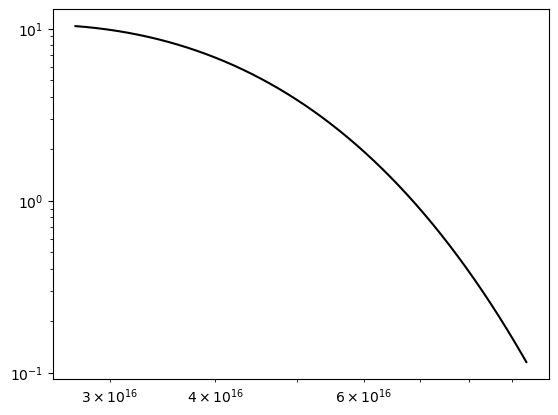

In [38]:

plt.plot(sorted_freq, wien_total, color='black', label="Wien's Law")
plt.yscale('log')  # Set x-axis to logarithmic scale
plt.xscale('log')  # Set x-axis to logarithmic scale


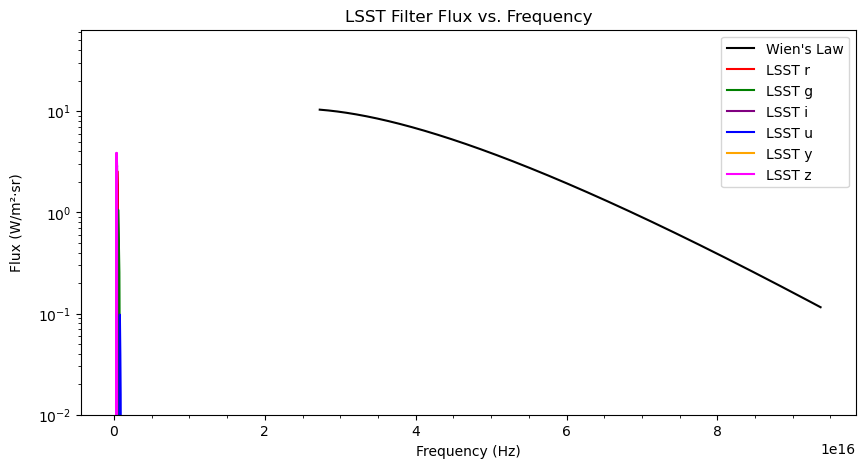

In [39]:
# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(sorted_freq, planck_total, color='black', label="Planck's Law")
    plt.plot(r_freq, r_planck, color='red', label='LSST r')
    plt.plot(g_freq, g_planck, color='green', label='LSST g')
    plt.plot(i_freq, i_planck, color='purple', label='LSST i')
    plt.plot(u_freq, u_planck, color='blue', label='LSST u')
    plt.plot(y_freq, y_planck, color='orange', label='LSST y')
    plt.plot(z_freq, z_planck, color='magenta', label='LSST z')
else:
    plt.plot(sorted_freq, wien_total, color='black', label="Wien's Law")
    plt.plot(r_freq, r_wien, color='red', label='LSST r')
    plt.plot(g_freq, g_wien, color='green', label='LSST g')
    plt.plot(i_freq, i_wien, color='purple', label='LSST i')
    plt.plot(u_freq, u_wien, color='blue', label='LSST u')
    plt.plot(y_freq, y_wien, color='orange', label='LSST y')
    plt.plot(z_freq, z_wien, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale

#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W/m²·sr)", labelpad=10)
plt.ylim(bottom=1e-2) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Flux vs. Frequency")
# plt.annotate(f'{u_ratio:.3g}', (7.8e14, 0.1e-8), fontsize=8, color='blue') #for u filter
# plt.annotate(f'{g_ratio:.3g}', (6.5e14, 0.1e-8), fontsize=8, color='green') #for g filter
# plt.annotate(f'{r_ratio:.3g}', (4.8e14, 0.1e-8), fontsize=8, color='red') #for r filter
# plt.annotate(f'{i_ratio:.3g}', (3.9e14, 0.1e-8), fontsize=10, color='purple') #for i filter
# plt.annotate(f'{y_ratio:.3g}', (2.9e14, 0.1e-8), fontsize=8, color='orange') #for y filter
# plt.annotate(f'{z_ratio:.3g}', (3.3e14, 0.1e-8), fontsize=8, color='magenta') #for z filter
plt.legend(loc='upper right')

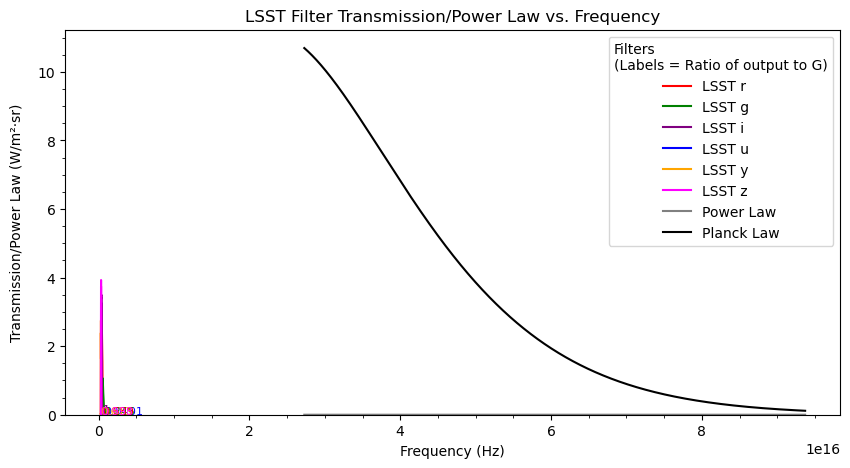

In [40]:
# Plot Code
plt.figure(figsize=(10, 5))
plt.plot(r_freq, r_planck, color='red', label='LSST r')
plt.plot(g_freq, g_planck, color='green', label='LSST g')
plt.plot(i_freq, i_planck, color='purple', label='LSST i')
plt.plot(u_freq, u_planck, color='blue', label='LSST u')
plt.plot(y_freq, y_planck, color='orange', label='LSST y')
plt.plot(z_freq, z_planck, color='magenta', label='LSST z')
#plt.plot(sorted_freq, planck_fxn(sorted_freq, t) / 2.2, label="Planck Func")
plt.plot(sorted_freq, 3e21 * sorted_freq ** -2, color='grey', label="Power Law") #power law for frequency
plt.plot(sorted_freq, planck_total, color='black', label="Planck Law")


#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Transmission/Power Law (W/m²·sr)", labelpad=10)
plt.ylim(bottom=0) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Transmission/Power Law vs. Frequency")
plt.annotate(f'{u_ratio:.3g}', (7.8e14, 0.1e-8), fontsize=8, color='blue') #for u filter
plt.annotate(f'{g_ratio:.3g}', (6.5e14, 0.1e-8), fontsize=8, color='green') #for g filter
plt.annotate(f'{r_ratio:.3g}', (4.8e14, 0.1e-8), fontsize=8, color='red') #for r filter
plt.annotate(f'{i_ratio:.3g}', (3.9e14, 0.1e-8), fontsize=10, color='purple') #for i filter
plt.annotate(f'{y_ratio:.3g}', (2.9e14, 0.1e-8), fontsize=8, color='orange') #for y filter
plt.annotate(f'{z_ratio:.3g}', (3.3e14, 0.1e-8), fontsize=8, color='magenta') #for z filter
plt.legend(title="Filters\n(Labels = Ratio of output to G)",loc='upper right')

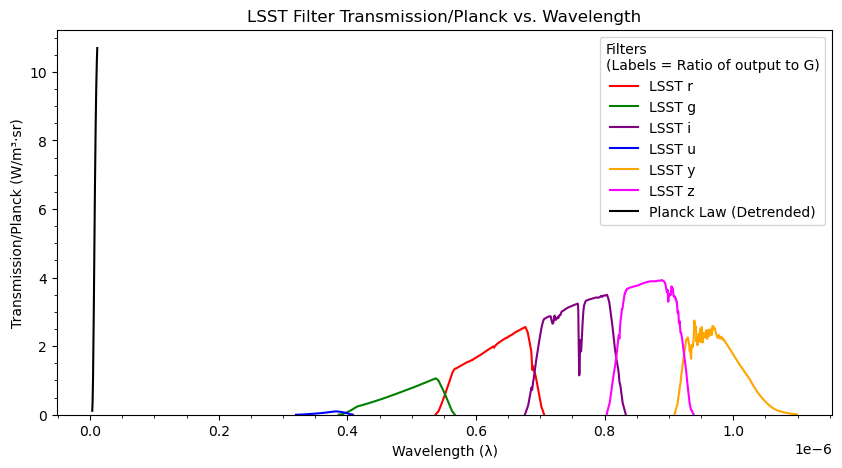

In [41]:
# Plot Code
plt.figure(figsize=(10, 5))
plt.plot(r_wave, r_planck, color='red', label='LSST r')
plt.plot(g_wave, g_planck, color='green', label='LSST g')
plt.plot(i_wave, i_planck, color='purple', label='LSST i')
plt.plot(u_wave, u_planck, color='blue', label='LSST u')
plt.plot(y_wave, y_planck, color='orange', label='LSST y')
plt.plot(z_wave, z_planck, color='magenta', label='LSST z')
plt.plot(total_wave, planck_total, color='black', label='Planck Law (Detrended)')
#plt.plot(total_wave, flux, color='gray', linestyle='--', label='Total Transmission')

# Plot Labels 
plt.ylim(bottom=0) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.xlabel("Wavelength (λ)")
plt.ylabel("Transmission/Planck (W/m³·sr)")
plt.title("LSST Filter Transmission/Planck vs. Wavelength")
plt.annotate(f'{u_ratio:.3g}', (0.34e-6, 0.1e13), fontsize=7, color='blue') #for u filter
plt.annotate(f'{g_ratio:.3g}', (0.47e-6, 0.1e13), fontsize=7, color='green') #for g filter
plt.annotate(f'{r_ratio:.3g}', (0.6e-6, 0.1e13), fontsize=7, color='red') #for r filter
plt.annotate(f'{i_ratio:.3g}', (0.73e-6, 0.1e13), fontsize=7, color='purple') #for i filter
plt.annotate(f'{y_ratio:.3g}', (0.95e-6, 0.1e13), fontsize=7, color='orange') #for y filter
plt.annotate(f'{z_ratio:.3g}', (0.85e-6, 0.1e13), fontsize=7, color='magenta') #for z filter
plt.legend(title="Filters\n(Labels = Ratio of output to G)",loc='upper right')